In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_iris, make_classification, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    cross_val_score, StratifiedKFold as SklearnStratifiedKFold,
)
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as SklearnLDA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from itertools import product
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print("All imports loaded successfully.")

All imports loaded successfully.


---
# 1) Principal Component Analysis (PCA)

**Why dimensionality reduction?**

High-dimensional data suffers from the **curse of dimensionality**: distances become meaningless, models overfit, and computation becomes prohibitive. PCA finds a lower-dimensional linear subspace that captures the maximum variance in the data.

**Geometric intuition:** Given a cloud of points in $\mathbb{R}^d$, PCA finds the orthogonal axes (principal components) along which the data varies the most. The first PC is the direction of maximum variance, the second PC is the direction of maximum variance orthogonal to the first, and so on.

**Key properties:**
- PCA is **unsupervised** — it ignores labels
- PCA finds directions of **maximum variance**, not maximum class separation
- The principal components are **orthonormal**
- PCA is equivalent to finding the **best rank-$k$ approximation** (Eckart-Young theorem)

## 1.1 Implementation

In [ ]:
class PCA:
    """Principal Component Analysis via eigendecomposition and SVD."""

    def __init__(self, num_components: int, method: str = "svd"):
        assert method in ("eigen", "svd"), "method must be 'eigen' or 'svd'"
        self.num_components = num_components
        self.method = method
        self.components_ = None
        self.eigenvalues_ = None
        self.mean_ = None
        self.explained_variance_ratio_ = None

    def fit(self, X: np.ndarray) -> "PCA":
        num_samples, num_features = X.shape

        # (num_features,)
        self.mean_ = X.mean(axis=0)

        # (num_samples, num_features)
        X_centered = X - self.mean_

        if self.method == "eigen":
            # (num_features, num_features)
            cov_matrix = (X_centered.T @ X_centered) / (num_samples - 1)

            # eigenvalues: (num_features,), eigenvectors: (num_features, num_features)
            eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

            # Sort descending — eigh returns ascending order
            sorted_idx = np.argsort(eigenvalues)[::-1]
            eigenvalues = eigenvalues[sorted_idx]
            eigenvectors = eigenvectors[:, sorted_idx]

            # (num_features, num_components)
            self.components_ = eigenvectors[:, :self.num_components]
            self.eigenvalues_ = eigenvalues[:self.num_components]

        else:
            # U: (num_samples, r),
            # S: (r,),
            # Vt: (r, num_features) where r = min(n, d)
            U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

            # Convert singular values to eigenvalues: lambda_i = sigma_i^2 / (n - 1)
            eigenvalues = (S ** 2) / (num_samples - 1)

            # (num_features, num_components) — rows of Vt are right singular vectors
            self.components_ = Vt[:self.num_components].T
            self.eigenvalues_ = eigenvalues[:self.num_components]

        total_variance = self.eigenvalues_.sum() if self.method == "eigen" else eigenvalues.sum()
        # Recompute total from all eigenvalues for ratio
        if self.method == "eigen":
            total_variance = eigenvalues.sum()
        else:
            total_variance = eigenvalues.sum()

        # (num_components,)
        self.explained_variance_ratio_ = self.eigenvalues_ / total_variance

        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        # (num_samples, num_features) @ (num_features, num_components) → (num_samples, num_components)
        return (X - self.mean_) @ self.components_

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        self.fit(X)
        return self.transform(X)

    def inverse_transform(self, Z: np.ndarray) -> np.ndarray:
        # (num_samples, num_components) @ (num_components, num_features) → (num_samples, num_features)
        return Z @ self.components_.T + self.mean_

    def reconstruction_error(self, X: np.ndarray) -> float:
        Z = self.transform(X)
        X_reconstructed = self.inverse_transform(Z)
        return np.mean((X - X_reconstructed) ** 2)


print("PCA class defined.")

PCA class defined.


In [ ]:
# Load and standardize the Iris dataset
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

scaler = StandardScaler()
# (150, 4)
X_iris_scaled = scaler.fit_transform(X_iris)

print(f"Iris dataset: {X_iris_scaled.shape[0]} samples, {X_iris_scaled.shape[1]} features")
print(f"Classes: {target_names}")
print(f"Class distribution: {np.bincount(y_iris)}")

Iris dataset: 150 samples, 4 features
Classes: ['setosa' 'versicolor' 'virginica']
Class distribution: [50 50 50]


In [ ]:
# Verify both methods produce identical results
pca_eigen = PCA(num_components=2, method="eigen").fit(X_iris_scaled)
pca_svd = PCA(num_components=2, method="svd").fit(X_iris_scaled)

Z_eigen = pca_eigen.transform(X_iris_scaled)
Z_svd = pca_svd.transform(X_iris_scaled)

# Sign ambiguity: eigenvectors may flip sign between methods
for i in range(2):
    if np.dot(pca_eigen.components_[:, i], pca_svd.components_[:, i]) < 0:
        Z_svd[:, i] *= -1

max_diff = np.max(np.abs(np.abs(Z_eigen) - np.abs(Z_svd)))
print(f"Max absolute difference between eigen and SVD projections: {max_diff:.2e}")
print(f"\nEigen method — Explained variance ratios: {pca_eigen.explained_variance_ratio_}")
print(f"SVD method   — Explained variance ratios: {pca_svd.explained_variance_ratio_}")
print(f"\nEigenvalues (eigen): {pca_eigen.eigenvalues_}")
print(f"Eigenvalues (SVD):   {pca_svd.eigenvalues_}")

Max absolute difference between eigen and SVD projections: 1.78e-15

Eigen method — Explained variance ratios: [0.72962445 0.22850762]
SVD method   — Explained variance ratios: [0.72962445 0.22850762]

Eigenvalues (eigen): [2.93808505 0.9201649 ]
Eigenvalues (SVD):   [2.93808505 0.9201649 ]


## 1.2 Explained Variance

The scree plot and cumulative explained variance curve guide the choice of $k$. Common heuristics:

1. **Kaiser criterion:** Keep components with $\lambda_i > 1$ (for standardized data, since each original variable contributes variance = 1).
2. **Elbow method:** Look for the "elbow" in the scree plot.
3. **Variance threshold:** Choose $k$ such that cumulative EVR exceeds a threshold (e.g., 95%).
4. **Cross-validation:** Use downstream task performance to select $k$.

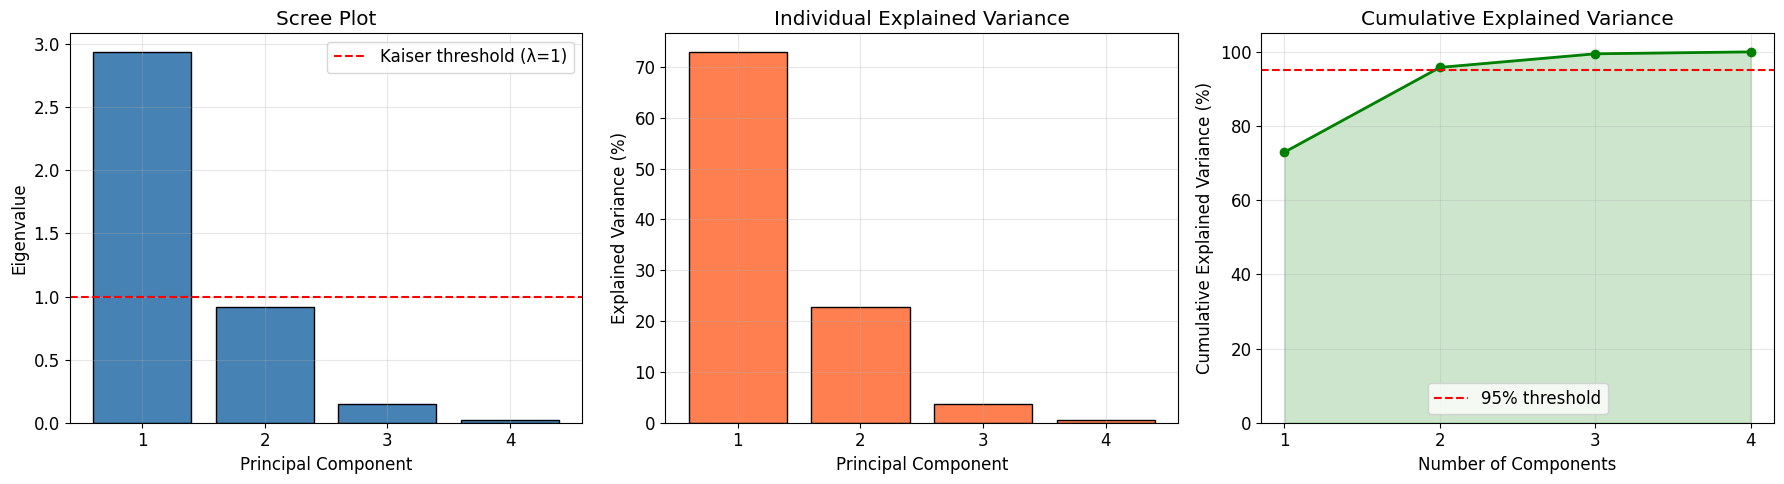

PC1: eigenvalue=2.9381, variance=72.96%, cumulative=72.96%
PC2: eigenvalue=0.9202, variance=22.85%, cumulative=95.81%
PC3: eigenvalue=0.1477, variance=3.67%, cumulative=99.48%
PC4: eigenvalue=0.0209, variance=0.52%, cumulative=100.00%


In [ ]:
# Fit PCA with all components to get full spectrum
pca_full = PCA(num_components=4, method="svd").fit(X_iris_scaled)

eigenvalues = pca_full.eigenvalues_
evr = pca_full.explained_variance_ratio_
cumulative_evr = np.cumsum(evr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scree plot
axes[0].bar(range(1, len(eigenvalues) + 1), eigenvalues, color="steelblue", edgecolor="black")
axes[0].axhline(y=1.0, color="red", linestyle="--", label="Kaiser threshold (λ=1)")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Eigenvalue")
axes[0].set_title("Scree Plot")
axes[0].set_xticks(range(1, len(eigenvalues) + 1))
axes[0].legend()

# Explained variance ratio
axes[1].bar(range(1, len(evr) + 1), evr * 100, color="coral", edgecolor="black")
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Explained Variance (%)")
axes[1].set_title("Individual Explained Variance")
axes[1].set_xticks(range(1, len(evr) + 1))

# Cumulative explained variance
axes[2].plot(range(1, len(cumulative_evr) + 1), cumulative_evr * 100, "o-", color="green", linewidth=2)
axes[2].axhline(y=95, color="red", linestyle="--", label="95% threshold")
axes[2].fill_between(range(1, len(cumulative_evr) + 1), cumulative_evr * 100, alpha=0.2, color="green")
axes[2].set_xlabel("Number of Components")
axes[2].set_ylabel("Cumulative Explained Variance (%)")
axes[2].set_title("Cumulative Explained Variance")
axes[2].set_xticks(range(1, len(cumulative_evr) + 1))
axes[2].set_ylim(0, 105)
axes[2].legend()

plt.tight_layout()
plt.show()

for i, (val, ratio, cum) in enumerate(zip(eigenvalues, evr, cumulative_evr)):
    print(f"PC{i+1}: eigenvalue={val:.4f}, variance={ratio*100:.2f}%, cumulative={cum*100:.2f}%")

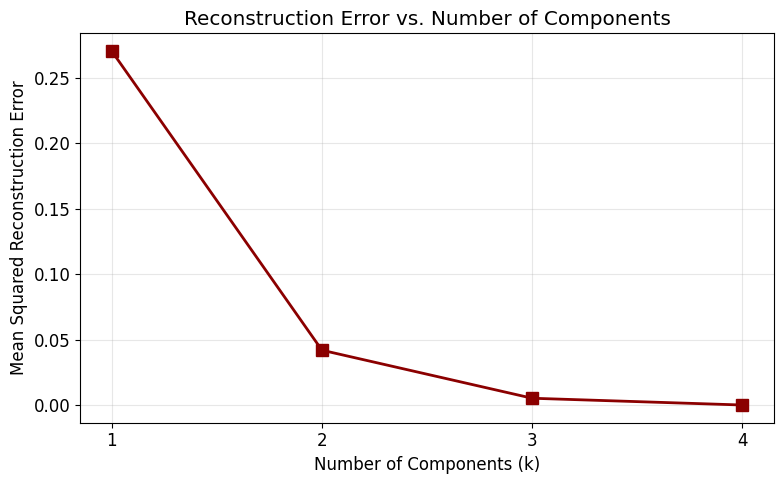

k=1: MSE = 0.270376
k=2: MSE = 0.041868
k=3: MSE = 0.005179
k=4: MSE = 0.000000


In [ ]:
# Reconstruction error as a function of num_components
errors = []
for k in range(1, X_iris_scaled.shape[1] + 1):
    pca_k = PCA(num_components=k, method="svd").fit(X_iris_scaled)
    errors.append(pca_k.reconstruction_error(X_iris_scaled))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(errors) + 1), errors, "s-", color="darkred", linewidth=2, markersize=8)
ax.set_xlabel("Number of Components (k)")
ax.set_ylabel("Mean Squared Reconstruction Error")
ax.set_title("Reconstruction Error vs. Number of Components")
ax.set_xticks(range(1, len(errors) + 1))
plt.tight_layout()
plt.show()

for k, err in enumerate(errors, 1):
    print(f"k={k}: MSE = {err:.6f}")

## 1.3 Visualization

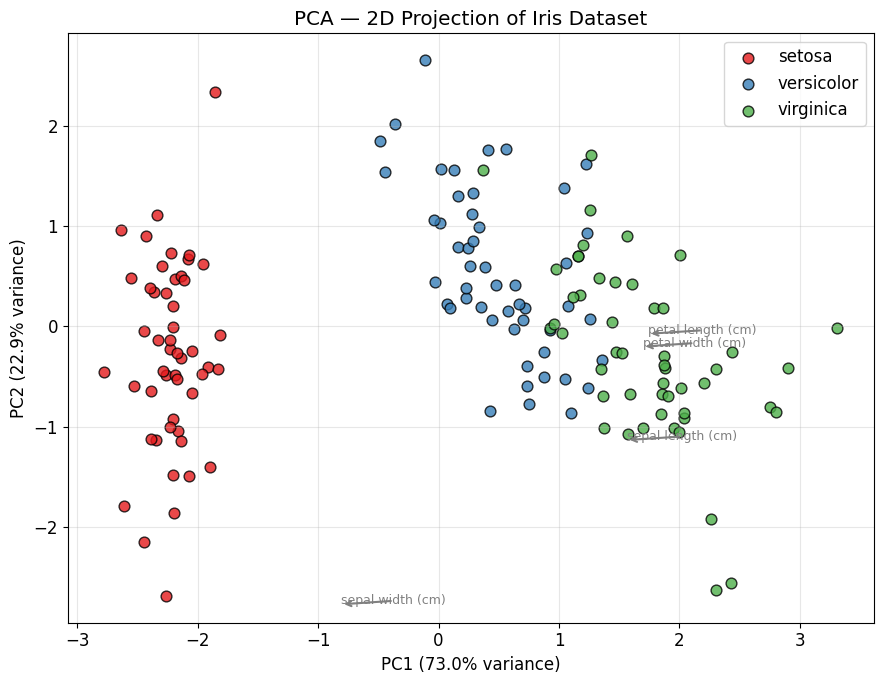

In [ ]:
# 2D PCA projection of Iris
pca_2d = PCA(num_components=2, method="svd").fit(X_iris_scaled)
Z_2d = pca_2d.transform(X_iris_scaled)

colors = ["#e41a1c", "#377eb8", "#4daf4a"]
fig, ax = plt.subplots(figsize=(9, 7))

for cls_idx, cls_name in enumerate(target_names):
    mask = y_iris == cls_idx
    ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1], c=colors[cls_idx],
               label=cls_name, s=60, edgecolors="black", alpha=0.8)

# Draw principal component directions from the origin
origin = pca_2d.transform(scaler.transform(np.zeros((1, 4))))[0]
for i, fname in enumerate(feature_names):
    ax.annotate(
        fname,
        xy=(pca_2d.components_[i, 0] * 3, pca_2d.components_[i, 1] * 3),
        arrowprops=dict(arrowstyle="->", color="gray", lw=1.5),
        fontsize=9, color="gray",
    )

evr_2d = pca_2d.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({evr_2d[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({evr_2d[1]*100:.1f}% variance)")
ax.set_title("PCA — 2D Projection of Iris Dataset")
ax.legend()
plt.tight_layout()
plt.show()

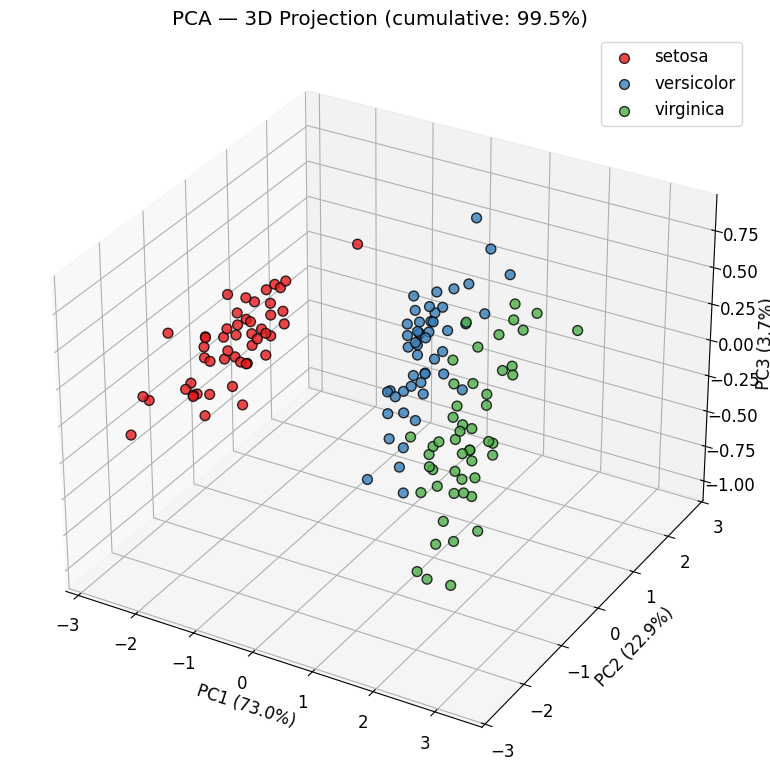

In [ ]:
# 3D PCA projection of Iris
pca_3d = PCA(num_components=3, method="svd").fit(X_iris_scaled)
Z_3d = pca_3d.transform(X_iris_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for cls_idx, cls_name in enumerate(target_names):
    mask = y_iris == cls_idx
    ax.scatter(Z_3d[mask, 0], Z_3d[mask, 1], Z_3d[mask, 2],
               c=colors[cls_idx], label=cls_name, s=50, edgecolors="black", alpha=0.8)

evr_3d = pca_3d.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({evr_3d[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({evr_3d[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({evr_3d[2]*100:.1f}%)")
ax.set_title(f"PCA — 3D Projection (cumulative: {sum(evr_3d)*100:.1f}%)")
ax.legend()
plt.tight_layout()
plt.show()

## 1.4 Comparison with sklearn

In [ ]:
# Compare our scratch PCA with sklearn's PCA
sklearn_pca = SklearnPCA(n_components=4).fit(X_iris_scaled)
ours_pca = PCA(num_components=4, method="svd").fit(X_iris_scaled)

print("Explained variance ratio comparison:")
print(f"  Ours:    {ours_pca.explained_variance_ratio_}")
print(f"  sklearn: {sklearn_pca.explained_variance_ratio_}")
print(f"  Max diff: {np.max(np.abs(ours_pca.explained_variance_ratio_ - sklearn_pca.explained_variance_ratio_)):.2e}")

Z_ours = ours_pca.transform(X_iris_scaled)
Z_sklearn = sklearn_pca.transform(X_iris_scaled)

# Handle sign ambiguity
for i in range(4):
    if np.corrcoef(Z_ours[:, i], Z_sklearn[:, i])[0, 1] < 0:
        Z_ours[:, i] *= -1

max_proj_diff = np.max(np.abs(Z_ours - Z_sklearn))
print(f"\nMax projection difference: {max_proj_diff:.2e}")
print("Implementations match!" if max_proj_diff < 1e-10 else "WARNING: mismatch detected")

Explained variance ratio comparison:
  Ours:    [0.72962445 0.22850762 0.03668922 0.00517871]
  sklearn: [0.72962445 0.22850762 0.03668922 0.00517871]
  Max diff: 4.44e-16

Max projection difference: 2.22e-15
Implementations match!


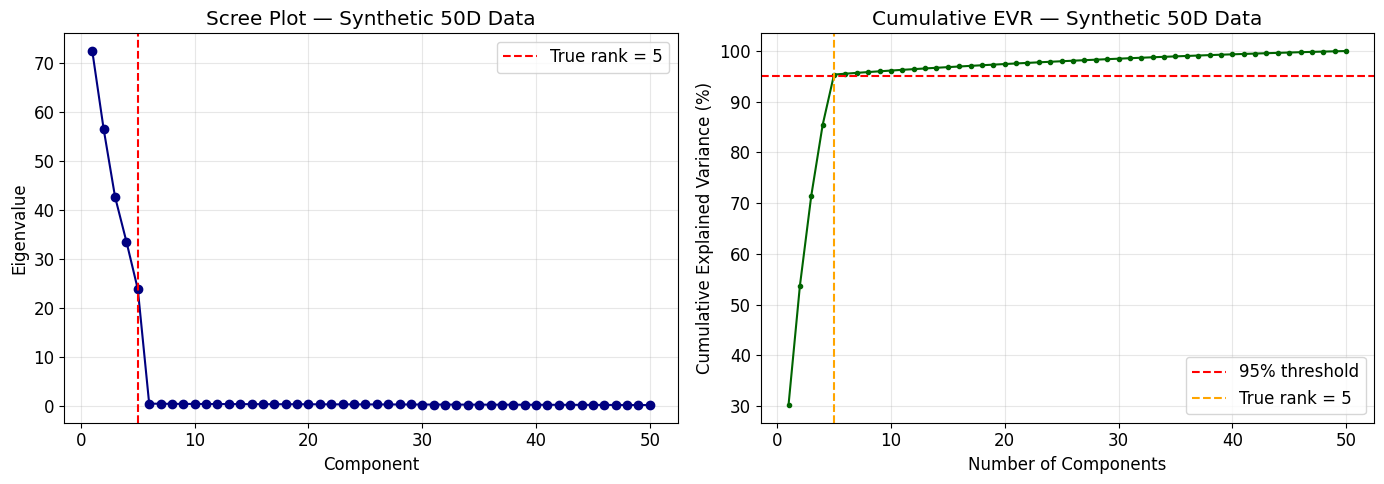

Components needed for 95% variance: 5 (true latent dim: 5)


In [ ]:
# High-dimensional synthetic data to demonstrate PCA scaling
num_samples, num_features_hd = 500, 50
num_informative = 5

# Create data where only a few directions carry signal
rng = np.random.RandomState(42)
# (num_informative, num_features_hd) — random projection matrix
A = rng.randn(num_informative, num_features_hd)
# (num_samples, num_informative) — latent factors
latent = rng.randn(num_samples, num_informative)
# (num_samples, num_features_hd) — projected + noise
X_hd = latent @ A + 0.5 * rng.randn(num_samples, num_features_hd)

pca_hd = PCA(num_components=num_features_hd, method="svd").fit(X_hd)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, num_features_hd + 1), pca_hd.eigenvalues_, "o-", color="navy")
axes[0].axvline(x=num_informative, color="red", linestyle="--", label=f"True rank = {num_informative}")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Eigenvalue")
axes[0].set_title("Scree Plot — Synthetic 50D Data")
axes[0].legend()

cum_evr_hd = np.cumsum(pca_hd.explained_variance_ratio_)
axes[1].plot(range(1, num_features_hd + 1), cum_evr_hd * 100, "o-", color="darkgreen", markersize=3)
axes[1].axhline(y=95, color="red", linestyle="--", label="95% threshold")
axes[1].axvline(x=num_informative, color="orange", linestyle="--", label=f"True rank = {num_informative}")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Cumulative EVR — Synthetic 50D Data")
axes[1].legend()

plt.tight_layout()
plt.show()

# Find k for 95% variance
k_95 = np.argmax(cum_evr_hd >= 0.95) + 1
print(f"Components needed for 95% variance: {k_95} (true latent dim: {num_informative})")

---
# 2) Linear Discriminant Analysis (LDA)

Unlike PCA which finds directions of maximum **variance** (unsupervised), LDA finds directions that maximize **class separation** (supervised).

## 2.1 Implementation

In [ ]:
class LDA:
    """Linear Discriminant Analysis — multi-class Fisher criterion."""

    def __init__(self, num_components: int = None, reg: float = 1e-6):
        self.num_components = num_components
        self.reg = reg
        self.components_ = None
        self.eigenvalues_ = None
        self.class_means_ = None
        self.overall_mean_ = None
        self.classes_ = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LDA":
        num_samples, num_features = X.shape
        self.classes_ = np.unique(y)
        num_classes = len(self.classes_)

        if self.num_components is None:
            self.num_components = min(num_features, num_classes - 1)

        # (num_features,)
        self.overall_mean_ = X.mean(axis=0)

        # Compute per-class means
        self.class_means_ = {}
        for c in self.classes_:
            self.class_means_[c] = X[y == c].mean(axis=0)

        # (num_features, num_features) — within-class scatter
        S_W = np.zeros((num_features, num_features))
        for c in self.classes_:
            # (num_samples_c, num_features)
            X_c = X[y == c]
            # (num_samples_c, num_features)
            diff = X_c - self.class_means_[c]
            # (num_features, num_samples_c) @ (num_samples_c, num_features) → (num_features, num_features)
            S_W += diff.T @ diff

        # Regularize S_W for numerical stability
        S_W += self.reg * np.eye(num_features)

        # (num_features, num_features) — between-class scatter
        S_B = np.zeros((num_features, num_features))
        for c in self.classes_:
            num_c = np.sum(y == c)
            # (num_features, 1)
            mean_diff = (self.class_means_[c] - self.overall_mean_).reshape(-1, 1)
            # (num_features, 1) @ (1, num_features) → (num_features, num_features)
            S_B += num_c * (mean_diff @ mean_diff.T)

        # Solve generalized eigenvalue problem: S_W^{-1} S_B w = lambda w
        # (num_features, num_features)
        M = np.linalg.solve(S_W, S_B)

        # eigenvalues: (num_features,), eigenvectors: (num_features, num_features)
        eigenvalues, eigenvectors = np.linalg.eig(M)

        # Eigenvalues may be complex due to numerical issues; take real parts
        eigenvalues = np.real(eigenvalues)
        eigenvectors = np.real(eigenvectors)

        # Sort by descending eigenvalue
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]

        # (num_features, num_components)
        self.components_ = eigenvectors[:, :self.num_components]
        self.eigenvalues_ = eigenvalues[:self.num_components]

        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        # (num_samples, num_features) @ (num_features, num_components) → (num_samples, num_components)
        return X @ self.components_

    def fit_transform(self, X: np.ndarray, y: np.ndarray) -> np.ndarray:
        self.fit(X, y)
        return self.transform(X)


print("LDA class defined.")

LDA class defined.


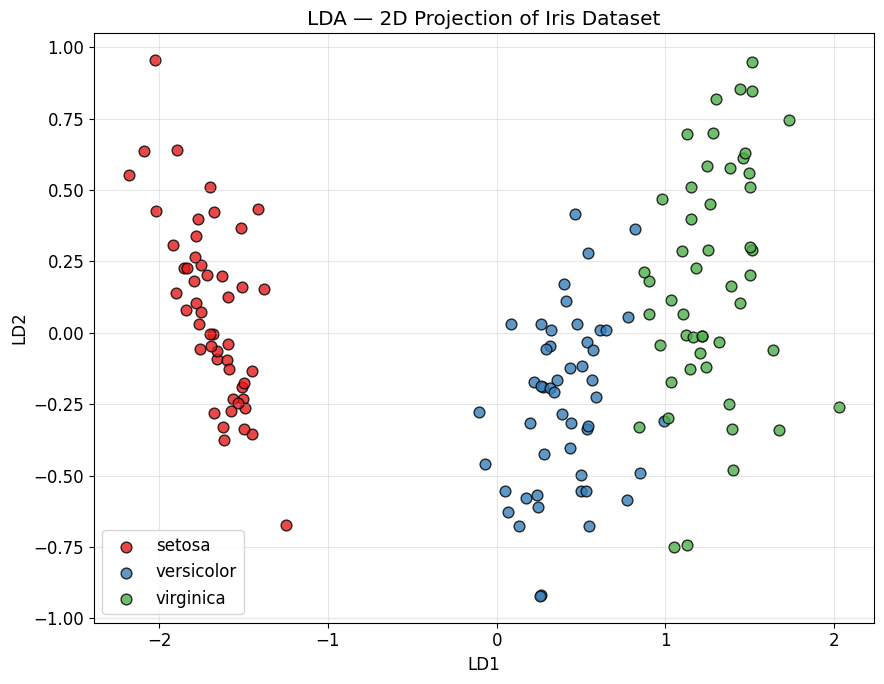

LDA eigenvalues: [32.19192472  0.28539103]


In [ ]:
# Fit LDA on Iris (3 classes → max 2 components)
lda = LDA(num_components=2).fit(X_iris_scaled, y_iris)

# (150, 2)
Z_lda = lda.transform(X_iris_scaled)

fig, ax = plt.subplots(figsize=(9, 7))

for cls_idx, cls_name in enumerate(target_names):
    mask = y_iris == cls_idx
    ax.scatter(Z_lda[mask, 0], Z_lda[mask, 1], c=colors[cls_idx],
               label=cls_name, s=60, edgecolors="black", alpha=0.8)

ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.set_title("LDA — 2D Projection of Iris Dataset")
ax.legend()
plt.tight_layout()
plt.show()

print(f"LDA eigenvalues: {lda.eigenvalues_}")

## 2.2 LDA vs PCA Comparison

The fundamental difference:
- **PCA** maximizes **total variance** — unsupervised, ignores labels
- **LDA** maximizes **class separability** — supervised, uses labels

When class separation is not aligned with the directions of maximum variance, PCA may project data into a space where classes overlap, while LDA will find a better projection.

| Property | PCA | LDA |
|----------|-----|-----|
| Supervision | Unsupervised | Supervised |
| Objective | Max variance | Max class separation |
| Max components | $\min(n, d)$ | $C - 1$ |
| Scatter matrices | $\Sigma$ (covariance) | $S_W^{-1} S_B$ |
| Sensitive to | Scale, outliers | Class overlap, singular $S_W$ |
| Use case | General dim. reduction | Classification preprocessing |

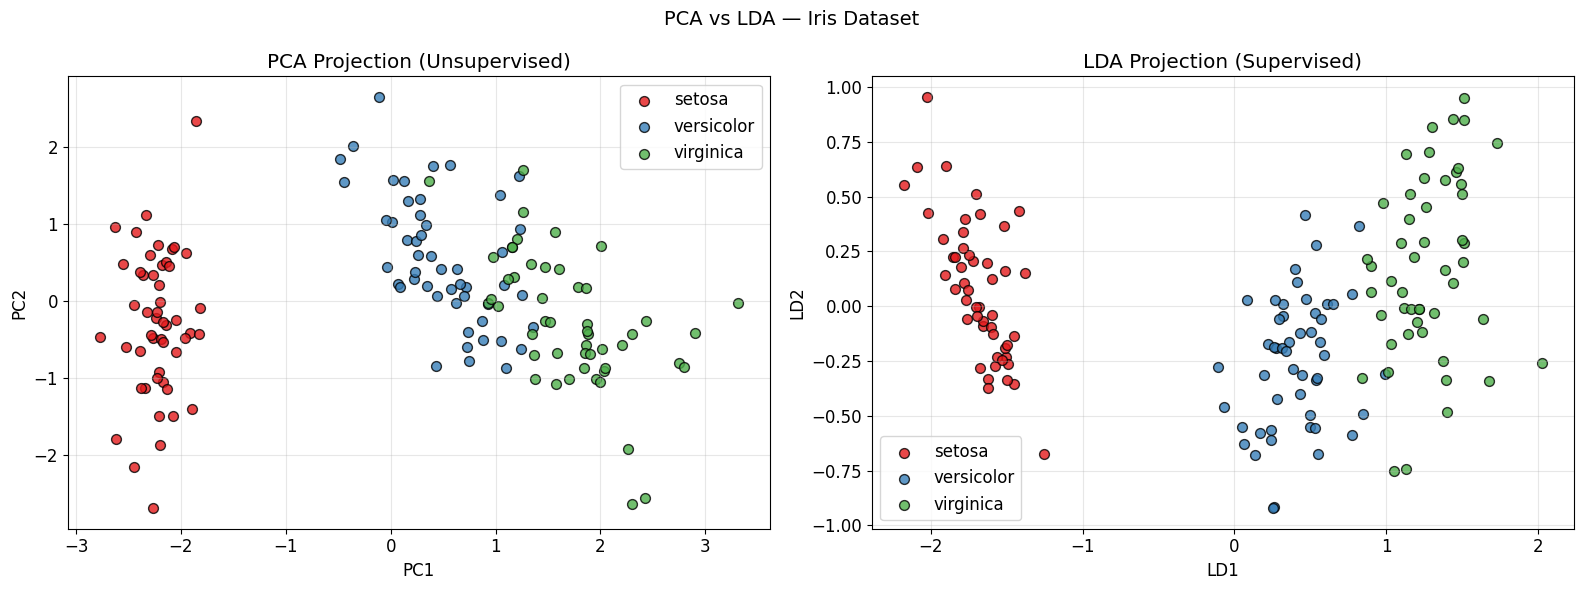

In [ ]:
# Side-by-side: PCA vs LDA on Iris
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

Z_pca = PCA(num_components=2, method="svd").fit_transform(X_iris_scaled)
Z_lda = LDA(num_components=2).fit_transform(X_iris_scaled, y_iris)

for cls_idx, cls_name in enumerate(target_names):
    mask = y_iris == cls_idx
    axes[0].scatter(Z_pca[mask, 0], Z_pca[mask, 1], c=colors[cls_idx],
                    label=cls_name, s=50, edgecolors="black", alpha=0.8)
    axes[1].scatter(Z_lda[mask, 0], Z_lda[mask, 1], c=colors[cls_idx],
                    label=cls_name, s=50, edgecolors="black", alpha=0.8)

axes[0].set_title("PCA Projection (Unsupervised)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

axes[1].set_title("LDA Projection (Supervised)")
axes[1].set_xlabel("LD1")
axes[1].set_ylabel("LD2")
axes[1].legend()

plt.suptitle("PCA vs LDA — Iris Dataset", fontsize=14)
plt.tight_layout()
plt.show()

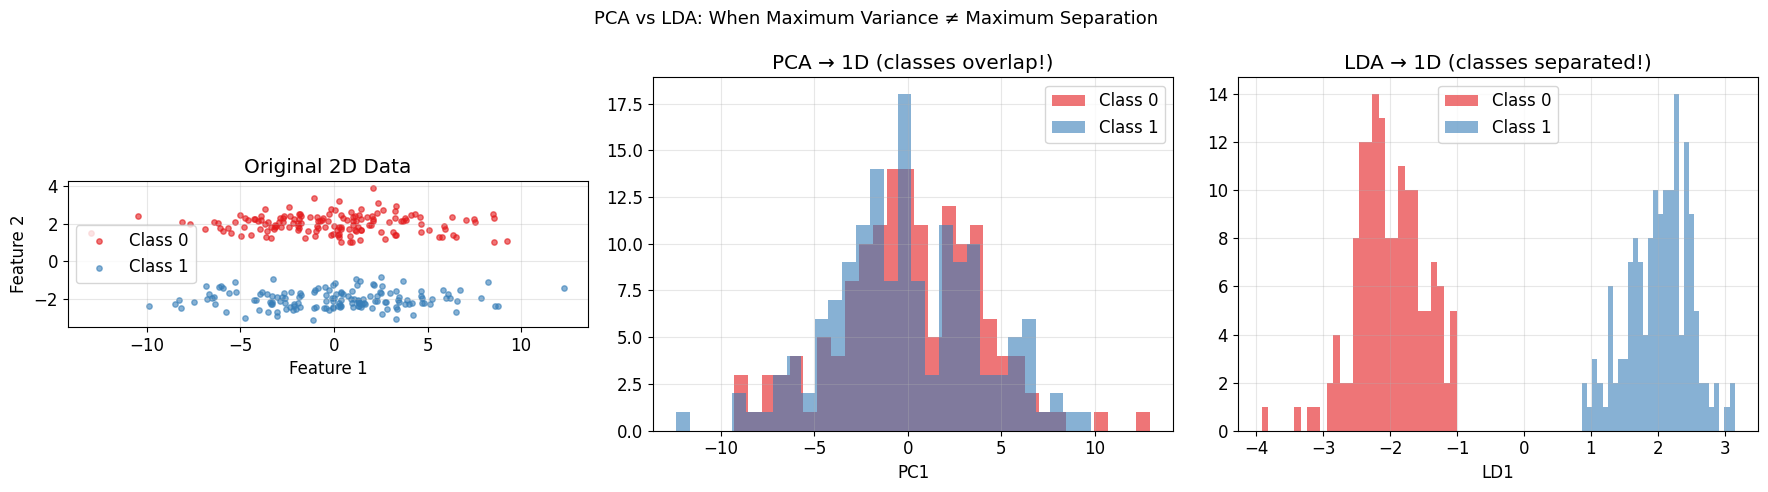

In [ ]:
# Demonstrate where PCA fails and LDA succeeds
# Create synthetic data where max-variance direction is NOT the best for classification
rng = np.random.RandomState(42)

# Class 0: elongated along x-axis, centered at (0, 0)
n_per_class = 150
X_c0 = rng.randn(n_per_class, 2) @ np.array([[4, 0], [0, 0.5]]) + np.array([0, 2])
X_c1 = rng.randn(n_per_class, 2) @ np.array([[4, 0], [0, 0.5]]) + np.array([0, -2])

X_synth = np.vstack([X_c0, X_c1])
y_synth = np.array([0] * n_per_class + [1] * n_per_class)

Z_pca_s = PCA(num_components=1, method="svd").fit_transform(X_synth)
Z_lda_s = LDA(num_components=1).fit_transform(X_synth, y_synth)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original data
for c, col in zip([0, 1], ["#e41a1c", "#377eb8"]):
    mask = y_synth == c
    axes[0].scatter(X_synth[mask, 0], X_synth[mask, 1], c=col, s=15, alpha=0.6, label=f"Class {c}")
axes[0].set_title("Original 2D Data")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].legend()
axes[0].set_aspect("equal")

# PCA 1D projection histogram
axes[1].hist(Z_pca_s[y_synth == 0], bins=30, alpha=0.6, color="#e41a1c", label="Class 0")
axes[1].hist(Z_pca_s[y_synth == 1], bins=30, alpha=0.6, color="#377eb8", label="Class 1")
axes[1].set_title("PCA → 1D (classes overlap!)")
axes[1].set_xlabel("PC1")
axes[1].legend()

# LDA 1D projection histogram
axes[2].hist(Z_lda_s[y_synth == 0], bins=30, alpha=0.6, color="#e41a1c", label="Class 0")
axes[2].hist(Z_lda_s[y_synth == 1], bins=30, alpha=0.6, color="#377eb8", label="Class 1")
axes[2].set_title("LDA → 1D (classes separated!)")
axes[2].set_xlabel("LD1")
axes[2].legend()

plt.suptitle("PCA vs LDA: When Maximum Variance ≠ Maximum Separation", fontsize=13)
plt.tight_layout()
plt.show()

## 2.3 Comparison with sklearn

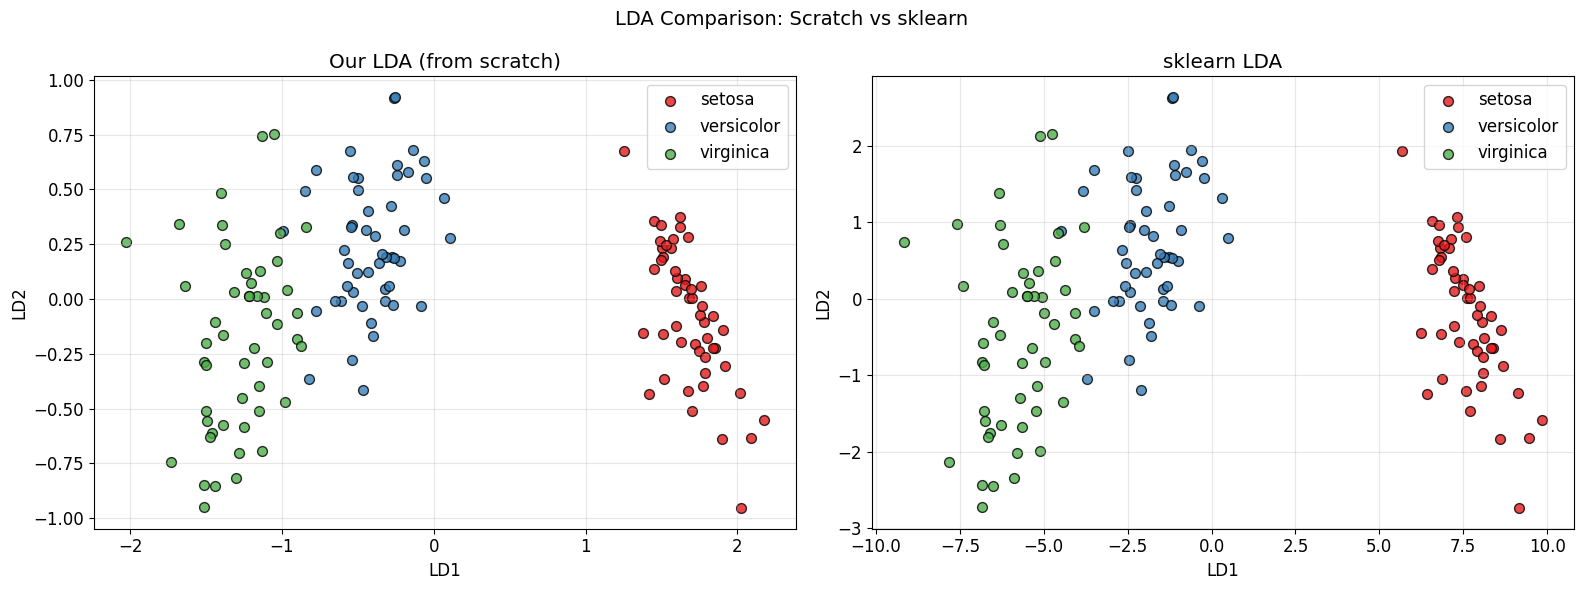

LD1 — correlation between ours and sklearn: 1.000000
LD2 — correlation between ours and sklearn: 1.000000


In [ ]:
# Compare our LDA with sklearn on Iris
sklearn_lda = SklearnLDA(n_components=2).fit(X_iris_scaled, y_iris)
ours_lda = LDA(num_components=2).fit(X_iris_scaled, y_iris)

Z_ours_lda = ours_lda.transform(X_iris_scaled)
Z_sklearn_lda = sklearn_lda.transform(X_iris_scaled)

# Handle sign ambiguity
for i in range(2):
    if np.corrcoef(Z_ours_lda[:, i], Z_sklearn_lda[:, i])[0, 1] < 0:
        Z_ours_lda[:, i] *= -1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cls_idx, cls_name in enumerate(target_names):
    mask = y_iris == cls_idx
    axes[0].scatter(Z_ours_lda[mask, 0], Z_ours_lda[mask, 1], c=colors[cls_idx],
                    label=cls_name, s=50, edgecolors="black", alpha=0.8)
    axes[1].scatter(Z_sklearn_lda[mask, 0], Z_sklearn_lda[mask, 1], c=colors[cls_idx],
                    label=cls_name, s=50, edgecolors="black", alpha=0.8)

axes[0].set_title("Our LDA (from scratch)")
axes[0].set_xlabel("LD1")
axes[0].set_ylabel("LD2")
axes[0].legend()

axes[1].set_title("sklearn LDA")
axes[1].set_xlabel("LD1")
axes[1].set_ylabel("LD2")
axes[1].legend()

plt.suptitle("LDA Comparison: Scratch vs sklearn", fontsize=14)
plt.tight_layout()
plt.show()

# Correlation between our and sklearn projections
for i in range(2):
    corr = np.abs(np.corrcoef(Z_ours_lda[:, i], Z_sklearn_lda[:, i])[0, 1])
    print(f"LD{i+1} — correlation between ours and sklearn: {corr:.6f}")

---
# 3) Model Selection and Hyperparameter Tuning

## 3.1 Train/Validation/Test Split

We want to estimate how well a model will perform on *unseen* data. Training error is optimistically biased (the model has already seen these samples).

### Three-Way Split

| Set | Purpose | Typical % |
|-----|---------|----------|
| Training | Learn model parameters ($\theta$) | 60–80% |
| Validation | Select hyperparameters, architecture | 10–20% |
| Test | Final unbiased performance estimate | 10–20% |

**Why not just train/test?** If we use the test set to tune hyperparameters, we leak information and the test score becomes an overly optimistic estimate of generalization.

**The bias-variance tradeoff in splitting:**
- Large training set → less bias in model, but less data for validation → higher variance in validation estimate
- Large validation set → better estimate of performance, but fewer training samples → higher bias in model

Cross-validation resolves this by using all data for both training and validation.

In [ ]:
# Prepare a classification dataset for cross-validation experiments
X_clf, y_clf = make_classification(
    n_samples=500, n_features=20, n_informative=10,
    n_redundant=5, n_classes=3, n_clusters_per_class=1,
    random_state=42,
)

# Hold out a final test set — never touched during model selection
X_dev, X_test_final, y_dev, y_test_final = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=42,
)

print(f"Development set: {X_dev.shape[0]} samples")
print(f"Final test set:  {X_test_final.shape[0]} samples")
print(f"Class distribution (dev):  {np.bincount(y_dev)}")
print(f"Class distribution (test): {np.bincount(y_test_final)}")

Development set: 400 samples
Final test set:  100 samples
Class distribution (dev):  [134 135 131]
Class distribution (test): [33 34 33]


## 3.2 K-Fold Cross Validation (from scratch)

**Idea:** Partition the data into $K$ roughly equal folds. For each fold $k$:
1. Train on all folds except $k$
2. Validate on fold $k$
3. Record the validation score

**Bias-variance of $K$:**
- Small $K$ (e.g., 2): Each training set is small → higher bias, but folds are more independent → lower variance
- Large $K$ (e.g., $n$, i.e. LOO): Each training set is nearly the full data → low bias, but folds are highly correlated → can have higher variance
- $K = 5$ or $K = 10$ is the standard compromise

In [ ]:
class KFold:
    """K-Fold cross-validation splitter (from scratch)."""

    def __init__(self, num_folds: int = 5, shuffle: bool = True, random_state: int = None):
        self.num_folds = num_folds
        self.shuffle = shuffle
        self.random_state = random_state

    def split(self, X: np.ndarray):
        num_samples = X.shape[0]
        indices = np.arange(num_samples)

        if self.shuffle:
            rng = np.random.RandomState(self.random_state)
            rng.shuffle(indices)

        # Compute fold boundaries — handles uneven splits via integer division
        fold_sizes = np.full(self.num_folds, num_samples // self.num_folds)
        fold_sizes[:num_samples % self.num_folds] += 1

        current = 0
        for fold_size in fold_sizes:
            val_idx = indices[current:current + fold_size]
            train_idx = np.concatenate([indices[:current], indices[current + fold_size:]])
            yield train_idx, val_idx
            current += fold_size


def cross_val_score_scratch(model_class, model_params, X, y, num_folds=5, random_state=42):
    """Compute cross-validation scores for a sklearn-compatible model."""
    kf = KFold(num_folds=num_folds, shuffle=True, random_state=random_state)
    scores = []

    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model = model_class(**model_params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        scores.append(accuracy_score(y_val, y_pred))

    return np.array(scores)


# Demo: K-Fold CV with SVC
scores = cross_val_score_scratch(SVC, {"kernel": "rbf", "C": 1.0}, X_dev, y_dev, num_folds=5)
print(f"5-Fold CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")
print(f"Per-fold scores: {scores}")

5-Fold CV Accuracy: 0.9625 ± 0.0137
Per-fold scores: [0.9625 0.95   0.9625 0.9875 0.95  ]


In [ ]:
# Verify our KFold produces valid, non-overlapping splits
kf = KFold(num_folds=5, shuffle=True, random_state=42)
all_val_indices = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_dev)):
    all_val_indices.append(val_idx)
    print(f"Fold {fold_idx}: train={len(train_idx)}, val={len(val_idx)}")

# Check that every sample appears exactly once in validation
all_val = np.concatenate(all_val_indices)
assert len(all_val) == len(X_dev), "Not all samples covered"
assert len(np.unique(all_val)) == len(X_dev), "Duplicate validation samples"
print(f"\nAll {len(X_dev)} samples appear exactly once in validation. Splits are valid.")

Fold 0: train=320, val=80
Fold 1: train=320, val=80
Fold 2: train=320, val=80
Fold 3: train=320, val=80
Fold 4: train=320, val=80

All 400 samples appear exactly once in validation. Splits are valid.


## 3.3 Stratified K-Fold

Standard K-Fold can produce folds with imbalanced class distributions (especially with small datasets or many classes). **Stratified K-Fold** ensures each fold has approximately the same class proportions as the full dataset.

**Algorithm:**
1. Group indices by class label
2. For each class, split its indices into $K$ sub-groups
3. Combine the $k$-th sub-group from each class to form fold $k$

In [ ]:
class StratifiedKFold:
    """Stratified K-Fold — preserves class proportions in each fold."""

    def __init__(self, num_folds: int = 5, shuffle: bool = True, random_state: int = None):
        self.num_folds = num_folds
        self.shuffle = shuffle
        self.random_state = random_state

    def split(self, X: np.ndarray, y: np.ndarray):
        rng = np.random.RandomState(self.random_state)
        classes = np.unique(y)

        # Group indices by class and optionally shuffle within each class
        class_indices = {}
        for c in classes:
            idx = np.where(y == c)[0]
            if self.shuffle:
                rng.shuffle(idx)
            class_indices[c] = idx

        # Build fold assignments: split each class's indices into K parts
        fold_indices = [[] for _ in range(self.num_folds)]
        for c in classes:
            idx = class_indices[c]
            fold_sizes = np.full(self.num_folds, len(idx) // self.num_folds)
            fold_sizes[:len(idx) % self.num_folds] += 1

            current = 0
            for k, size in enumerate(fold_sizes):
                fold_indices[k].extend(idx[current:current + size])
                current += size

        for k in range(self.num_folds):
            val_idx = np.array(fold_indices[k])
            train_idx = np.concatenate([np.array(fold_indices[j]) for j in range(self.num_folds) if j != k])
            yield train_idx, val_idx


# Verify class proportions are preserved
skf = StratifiedKFold(num_folds=5, shuffle=True, random_state=42)
overall_dist = np.bincount(y_dev) / len(y_dev)
print(f"Overall class distribution: {overall_dist}")
print()

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_dev, y_dev)):
    fold_dist = np.bincount(y_dev[val_idx], minlength=3) / len(val_idx)
    print(f"Fold {fold_idx}: val size={len(val_idx)}, class dist={fold_dist}")

Overall class distribution: [0.335  0.3375 0.3275]

Fold 0: val size=81, class dist=[0.33333333 0.33333333 0.33333333]
Fold 1: val size=80, class dist=[0.3375 0.3375 0.325 ]
Fold 2: val size=80, class dist=[0.3375 0.3375 0.325 ]
Fold 3: val size=80, class dist=[0.3375 0.3375 0.325 ]
Fold 4: val size=79, class dist=[0.32911392 0.34177215 0.32911392]


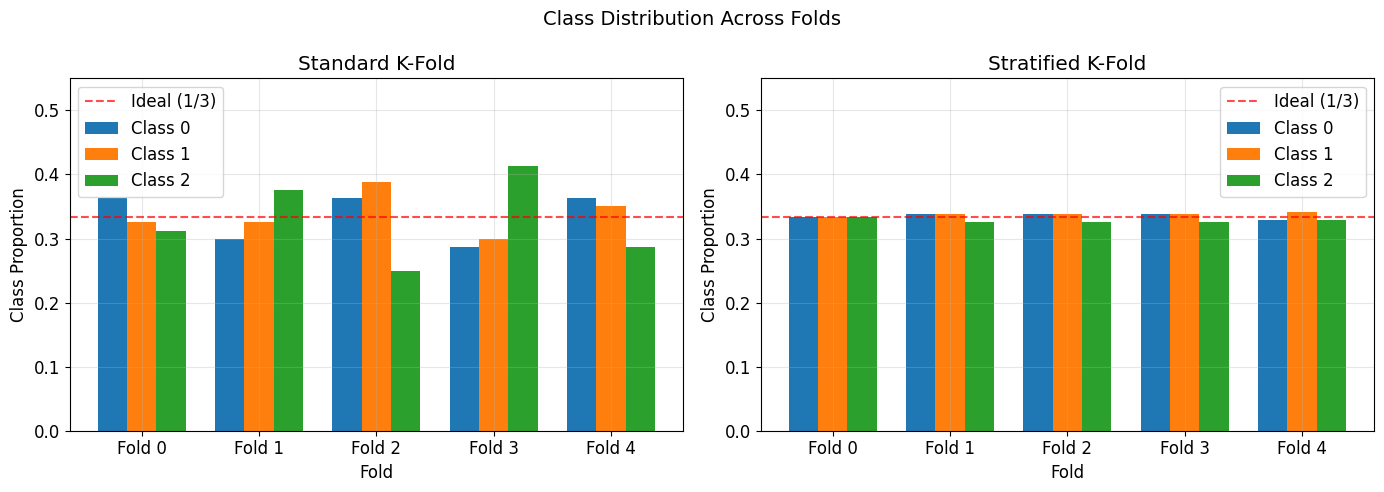

In [ ]:
# Compare standard vs stratified K-Fold on class distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Standard K-Fold fold distributions
kf_standard = KFold(num_folds=5, shuffle=True, random_state=42)
kf_strat = StratifiedKFold(num_folds=5, shuffle=True, random_state=42)

for ax, splitter, title in [
    (axes[0], kf_standard, "Standard K-Fold"),
    (axes[1], kf_strat, "Stratified K-Fold"),
]:
    fold_dists = []
    split_gen = splitter.split(X_dev, y_dev) if title.startswith("Strat") else splitter.split(X_dev)
    for train_idx, val_idx in split_gen:
        fold_dists.append(np.bincount(y_dev[val_idx], minlength=3) / len(val_idx))

    fold_dists = np.array(fold_dists)
    x = np.arange(5)
    width = 0.25
    for c in range(3):
        ax.bar(x + c * width, fold_dists[:, c], width, label=f"Class {c}")
    ax.axhline(y=1/3, color="red", linestyle="--", alpha=0.7, label="Ideal (1/3)")
    ax.set_xlabel("Fold")
    ax.set_ylabel("Class Proportion")
    ax.set_title(title)
    ax.set_xticks(x + width)
    ax.set_xticklabels([f"Fold {i}" for i in range(5)])
    ax.legend()
    ax.set_ylim(0, 0.55)

plt.suptitle("Class Distribution Across Folds", fontsize=14)
plt.tight_layout()
plt.show()

## 3.4 Leave-One-Out Cross Validation

**LOOCV** is the extreme case of K-Fold where $K = n$. Each fold contains exactly one validation sample.

**Pros:**
- Nearly unbiased estimate (training on $n - 1$ samples)
- Deterministic — no randomness from fold assignment

**Cons:**
- Computationally expensive: $n$ model fits
- High variance: each training set differs by only 1 sample, so model estimates are highly correlated
- For certain models (linear regression), a closed-form shortcut exists

In [ ]:
class LeaveOneOut:
    """Leave-One-Out CV — equivalent to K-Fold with K=n."""

    def split(self, X: np.ndarray):
        num_samples = X.shape[0]
        for i in range(num_samples):
            val_idx = np.array([i])
            train_idx = np.concatenate([np.arange(0, i), np.arange(i + 1, num_samples)])
            yield train_idx, val_idx


# Demo LOOCV on a small subset for speed
X_small, y_small = X_dev[:80], y_dev[:80]

loo = LeaveOneOut()
loo_scores = []

for train_idx, val_idx in loo.split(X_small):
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_small[train_idx], y_small[train_idx])
    pred = model.predict(X_small[val_idx])
    loo_scores.append(int(pred[0] == y_small[val_idx[0]]))

loo_acc = np.mean(loo_scores)
print(f"LOO-CV Accuracy (k-NN, n={len(X_small)}): {loo_acc:.4f}")
print(f"Number of model fits: {len(X_small)}")

LOO-CV Accuracy (k-NN, n=80): 0.8875
Number of model fits: 80


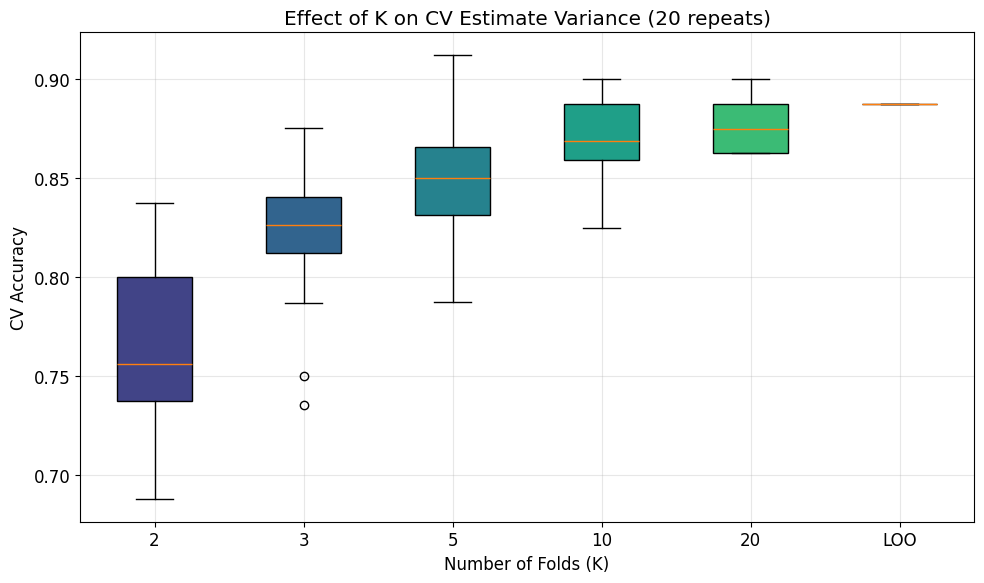

In [ ]:
# Compare different K values — bias-variance of CV estimate
k_values = [2, 3, 5, 10, 20, len(X_small)]
k_labels = [str(k) if k != len(X_small) else "LOO" for k in k_values]

# Run each K-fold 20 times with different random seeds to estimate variance
num_repeats = 20
results = {}

for k, label in zip(k_values, k_labels):
    repeat_means = []
    for seed in range(num_repeats):
        if k == len(X_small):
            scores = loo_scores
        else:
            scores = cross_val_score_scratch(
                KNeighborsClassifier, {"n_neighbors": 5},
                X_small, y_small, num_folds=k, random_state=seed,
            )
        repeat_means.append(np.mean(scores))
    results[label] = repeat_means

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot([results[l] for l in k_labels], labels=k_labels, patch_artist=True)
for patch, color in zip(bp["boxes"], plt.cm.viridis(np.linspace(0.2, 0.8, len(k_labels)))):
    patch.set_facecolor(color)

ax.set_xlabel("Number of Folds (K)")
ax.set_ylabel("CV Accuracy")
ax.set_title("Effect of K on CV Estimate Variance (20 repeats)")
plt.tight_layout()
plt.show()

## 3.5 GridSearchCV

**GridSearchCV** exhaustively evaluates every combination of hyperparameters from a predefined grid, using cross-validation for each combination.

**Complexity:** If grid has $m$ total combinations and we use $K$ folds, we fit $m \times K$ models.

**When to use:** Small parameter grids, computationally cheap models, or when you need exhaustive coverage.

In [ ]:
# sklearn GridSearchCV demo with internal inspection
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1],
    "kernel": ["rbf"],
}

grid_search = GridSearchCV(
    SVC(), param_grid, cv=5, scoring="accuracy",
    return_train_score=True, verbose=0,
)
grid_search.fit(X_dev, y_dev)

num_combinations = len(param_grid["C"]) * len(param_grid["gamma"]) * len(param_grid["kernel"])
num_fits = num_combinations * 5

print(f"Parameter combinations: {num_combinations}")
print(f"Total model fits (combinations × folds): {num_fits}")
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

Parameter combinations: 20
Total model fits (combinations × folds): 100

Best parameters: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV accuracy: 0.9575


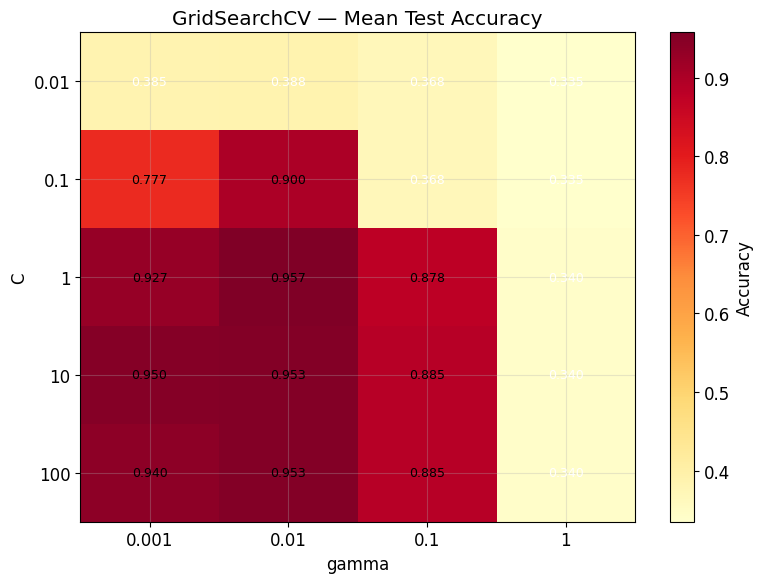

In [ ]:
# Visualize GridSearch results as a heatmap
results_df = grid_search.cv_results_
C_values = param_grid["C"]
gamma_values = param_grid["gamma"]

# (len(C_values), len(gamma_values))
score_matrix = np.array(results_df["mean_test_score"]).reshape(len(C_values), len(gamma_values))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(score_matrix, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(gamma_values)))
ax.set_xticklabels([str(g) for g in gamma_values])
ax.set_yticks(range(len(C_values)))
ax.set_yticklabels([str(c) for c in C_values])
ax.set_xlabel("gamma")
ax.set_ylabel("C")
ax.set_title("GridSearchCV — Mean Test Accuracy")

# Annotate cells with scores
for i in range(len(C_values)):
    for j in range(len(gamma_values)):
        ax.text(j, i, f"{score_matrix[i, j]:.3f}",
                ha="center", va="center", fontsize=9,
                color="white" if score_matrix[i, j] < 0.7 else "black")

plt.colorbar(im, label="Accuracy")
plt.tight_layout()
plt.show()

## 3.6 RandomizedSearchCV

**RandomizedSearchCV** samples hyperparameter combinations randomly from specified distributions, rather than exhaustively evaluating a grid.

### Algorithm

```
Input: model class, param_distributions, n_iter, data (X, y), K folds
For i = 1 to n_iter:
    Sample (p1, p2, ...) from param_distributions
    scores = k_fold_cv(model(p1, p2, ...), X, y, K)
    mean_score[i] = mean(scores)
Return: params with highest mean_score, refit model on full data
```

**Bergstra & Bengio (2012)** showed that random search is more efficient than grid search when:
- Only a few hyperparameters actually matter (low effective dimensionality)
- Grid search wastes evaluations on unimportant parameter combinations
- Random search explores more unique values of each important parameter

**Key insight:** In a $d$-dimensional grid with $m$ values per dimension, grid search places $m$ unique values on each axis but requires $m^d$ evaluations. Random search with $m^d$ samples places $m^d$ unique values on each axis — much better coverage per dimension.

**When to use:** Large parameter spaces, expensive model fitting, or when you suspect only a few parameters matter.

In [ ]:
from scipy.stats import loguniform, uniform, randint

param_distributions = {
    "C": loguniform(1e-3, 1e3),
    "gamma": loguniform(1e-4, 1e1),
    "kernel": ["rbf"],
}

random_search = RandomizedSearchCV(
    SVC(), param_distributions, n_iter=40, cv=5,
    scoring="accuracy", random_state=42, return_train_score=True,
)
random_search.fit(X_dev, y_dev)

print(f"Number of iterations: 40")
print(f"Total model fits: {40 * 5}")
print(f"\nBest parameters: {random_search.best_params_}")
print(f"Best CV accuracy: {random_search.best_score_:.4f}")
print(f"\nGridSearch best:   {grid_search.best_score_:.4f} ({num_fits} fits)")
print(f"RandomSearch best: {random_search.best_score_:.4f} (200 fits)")

Number of iterations: 40
Total model fits: 200

Best parameters: {'C': np.float64(93.84800715909533), 'gamma': np.float64(0.0060780830996819525), 'kernel': 'rbf'}
Best CV accuracy: 0.9525

GridSearch best:   0.9575 (100 fits)
RandomSearch best: 0.9525 (200 fits)


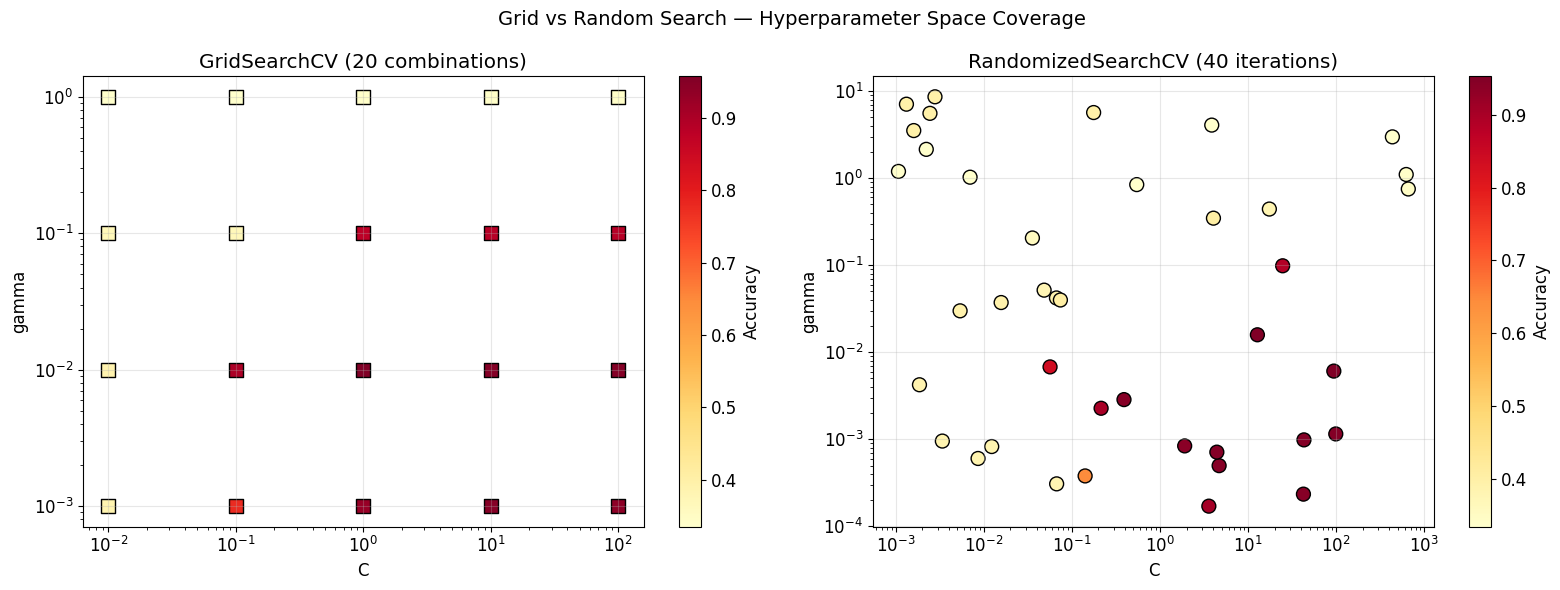

In [ ]:
# Visualize RandomSearch exploration vs GridSearch
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grid search points
grid_Cs = results_df["param_C"].data
grid_gammas = results_df["param_gamma"].data
grid_scores = results_df["mean_test_score"]

sc1 = axes[0].scatter(grid_Cs, grid_gammas, c=grid_scores, cmap="YlOrRd",
                       s=100, edgecolors="black", marker="s")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("C")
axes[0].set_ylabel("gamma")
axes[0].set_title(f"GridSearchCV ({num_combinations} combinations)")
plt.colorbar(sc1, ax=axes[0], label="Accuracy")

# Random search points
rand_Cs = random_search.cv_results_["param_C"].data
rand_gammas = random_search.cv_results_["param_gamma"].data
rand_scores = random_search.cv_results_["mean_test_score"]

sc2 = axes[1].scatter(rand_Cs, rand_gammas, c=rand_scores, cmap="YlOrRd",
                       s=100, edgecolors="black", marker="o")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("C")
axes[1].set_ylabel("gamma")
axes[1].set_title(f"RandomizedSearchCV (40 iterations)")
plt.colorbar(sc2, ax=axes[1], label="Accuracy")

plt.suptitle("Grid vs Random Search — Hyperparameter Space Coverage", fontsize=14)
plt.tight_layout()
plt.show()

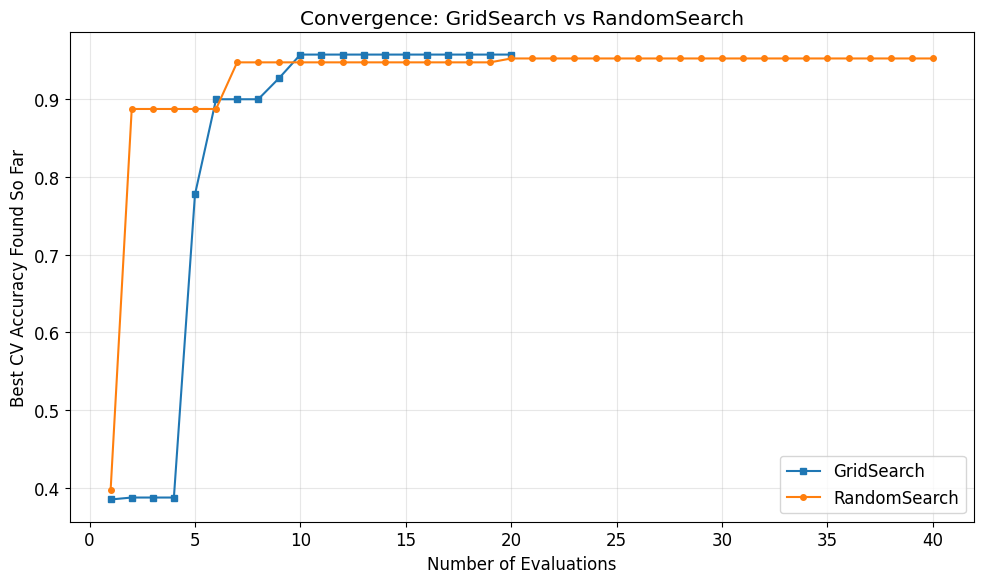

In [ ]:
# Convergence comparison: best score found vs number of evaluations
grid_sorted = np.sort(grid_scores)[::-1]
rand_sorted = np.sort(rand_scores)[::-1]

grid_cummax = np.maximum.accumulate(grid_scores)
rand_cummax = np.maximum.accumulate(rand_scores)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(grid_cummax) + 1), grid_cummax, "s-", label="GridSearch", markersize=4)
ax.plot(range(1, len(rand_cummax) + 1), rand_cummax, "o-", label="RandomSearch", markersize=4)
ax.set_xlabel("Number of Evaluations")
ax.set_ylabel("Best CV Accuracy Found So Far")
ax.set_title("Convergence: GridSearch vs RandomSearch")
ax.legend()
plt.tight_layout()
plt.show()

## 3.7 Bayesian Optimization

Both GridSearch and RandomSearch are **uninformed** — they don't use results from previous evaluations to guide future ones. Bayesian Optimization (BO) is a **sequential, model-based** approach.

### Core Idea

1. Build a **surrogate model** $\hat{f}(\theta)$ of the objective function (e.g., CV accuracy as a function of hyperparameters $\theta$)
2. Use an **acquisition function** to decide which $\theta$ to evaluate next, balancing exploration (uncertain regions) vs exploitation (promising regions)
3. Evaluate the true objective at $\theta^*$, update the surrogate, repeat

### Surrogate Models

- **Gaussian Process (GP):** Most common. Provides mean prediction and uncertainty. Cost: $O(n^3)$ per update. Used in `BayesSearchCV` (scikit-optimize).
- **Tree-Structured Parzen Estimator (TPE):** Models $p(\theta | y < y^*)$ and $p(\theta | y \geq y^*)$ separately. Used in Optuna and Hyperopt.
- **Random Forests:** Used in SMAC (Sequential Model-based Algorithm Configuration).

### Acquisition Functions

- **Expected Improvement (EI):** $\text{EI}(\theta) = \mathbb{E}[\max(f(\theta) - f^*, 0)]$ — most popular
- **Upper Confidence Bound (UCB):** $\text{UCB}(\theta) = \mu(\theta) + \kappa \sigma(\theta)$
- **Probability of Improvement (PI):** $\text{PI}(\theta) = P(f(\theta) > f^*)$

### Comparison

| Method | Evaluations to converge | Parallelizable | Handles conditionals |
|--------|------------------------|----------------|---------------------|
| GridSearch | $m^d$ (exponential) | Yes | No |
| RandomSearch | $O(1/\epsilon^d)$ but better constants | Yes | No |
| Bayesian Opt | Much fewer (10-100x less) | Limited | TPE: Yes |

**When to use BO:** Expensive model training (deep learning, large datasets), moderate-dimensional parameter spaces ($d < 20$), when you have a limited compute budget.

## 3.8: Full Pipeline

Putting all together:
- PCA for dimensionality reduction
- Stratified K-fold CV
- Hyperparameter search
- Final evaluation on the held-out test set.

In [ ]:
# Full pipeline: PCA → SVC with stratified CV hyperparameter search
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA as SkPCA

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", SkPCA()),
    ("svc", SVC()),
])

# Search over PCA components and SVC hyperparameters jointly
pipe_param_grid = {
    "pca__n_components": [5, 10, 15],
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": [0.001, 0.01, 0.1],
    "svc__kernel": ["rbf"],
}

# Use stratified 5-fold (sklearn) for the search
pipe_search = GridSearchCV(
    pipe, pipe_param_grid, cv=SklearnStratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy", return_train_score=True, n_jobs=-1,
)
pipe_search.fit(X_dev, y_dev)

print("Best pipeline parameters:")
for param, val in pipe_search.best_params_.items():
    print(f"  {param}: {val}")
print(f"\nBest CV accuracy: {pipe_search.best_score_:.4f}")

Best pipeline parameters:
  pca__n_components: 15
  svc__C: 10
  svc__gamma: 0.01
  svc__kernel: rbf

Best CV accuracy: 0.9600


In [ ]:
# Final evaluation on held-out test set
best_model = pipe_search.best_estimator_
y_test_pred = best_model.predict(X_test_final)
test_acc = accuracy_score(y_test_final, y_test_pred)

print(f"Final test accuracy: {test_acc:.4f}")
print(f"CV estimate was:     {pipe_search.best_score_:.4f}")
print(f"Gap (overfitting):   {pipe_search.best_score_ - test_acc:.4f}")

Final test accuracy: 0.9900
CV estimate was:     0.9600
Gap (overfitting):   -0.0300


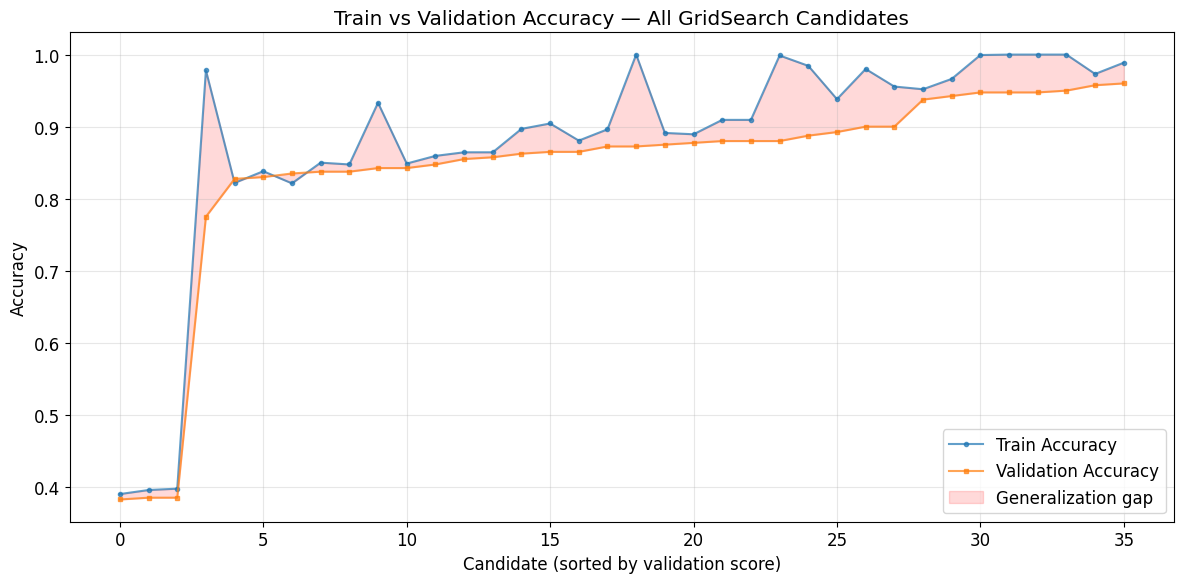

In [ ]:
# Visualize train vs validation accuracy across all grid search candidates
train_scores = pipe_search.cv_results_["mean_train_score"]
test_scores = pipe_search.cv_results_["mean_test_score"]

# Sort by test score for cleaner visualization
sort_idx = np.argsort(test_scores)
train_sorted = train_scores[sort_idx]
test_sorted = test_scores[sort_idx]

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(train_sorted))
ax.plot(x, train_sorted, "o-", label="Train Accuracy", markersize=3, alpha=0.7)
ax.plot(x, test_sorted, "s-", label="Validation Accuracy", markersize=3, alpha=0.7)
ax.fill_between(x, test_sorted, train_sorted, alpha=0.15, color="red", label="Generalization gap")
ax.set_xlabel("Candidate (sorted by validation score)")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs Validation Accuracy — All GridSearch Candidates")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Compare all search strategies on the same problem
# Use Random Forest this time for variety
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
}

rf_param_dist = {
    "n_estimators": randint(20, 300),
    "max_depth": [3, 5, 10, 15, 20, None],
    "min_samples_split": randint(2, 20),
}

cv_strat = SklearnStratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearch
gs = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid,
                  cv=cv_strat, scoring="accuracy", n_jobs=-1)
gs.fit(X_dev, y_dev)

# RandomSearch with same budget as grid
num_grid_combos = 3 * 4 * 3
rs = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_param_dist,
                        n_iter=num_grid_combos, cv=cv_strat, scoring="accuracy",
                        random_state=42, n_jobs=-1)
rs.fit(X_dev, y_dev)

# Our from-scratch stratified K-Fold with the best params from grid search
our_skf = StratifiedKFold(num_folds=5, shuffle=True, random_state=42)
our_scores = []
for train_idx, val_idx in our_skf.split(X_dev, y_dev):
    rf = RandomForestClassifier(**gs.best_params_, random_state=42)
    rf.fit(X_dev[train_idx], y_dev[train_idx])
    our_scores.append(accuracy_score(y_dev[val_idx], rf.predict(X_dev[val_idx])))

print(f"GridSearch best:        {gs.best_score_:.4f} | params: {gs.best_params_}")
print(f"RandomSearch best:      {rs.best_score_:.4f} | params: {rs.best_params_}")
print(f"Our StratifiedKFold:    {np.mean(our_scores):.4f} ± {np.std(our_scores):.4f} (with GS best params)")

GridSearch best:        0.9350 | params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
RandomSearch best:      0.9375 | params: {'max_depth': 15, 'min_samples_split': 9, 'n_estimators': 233}
Our StratifiedKFold:    0.9098 ± 0.0350 (with GS best params)


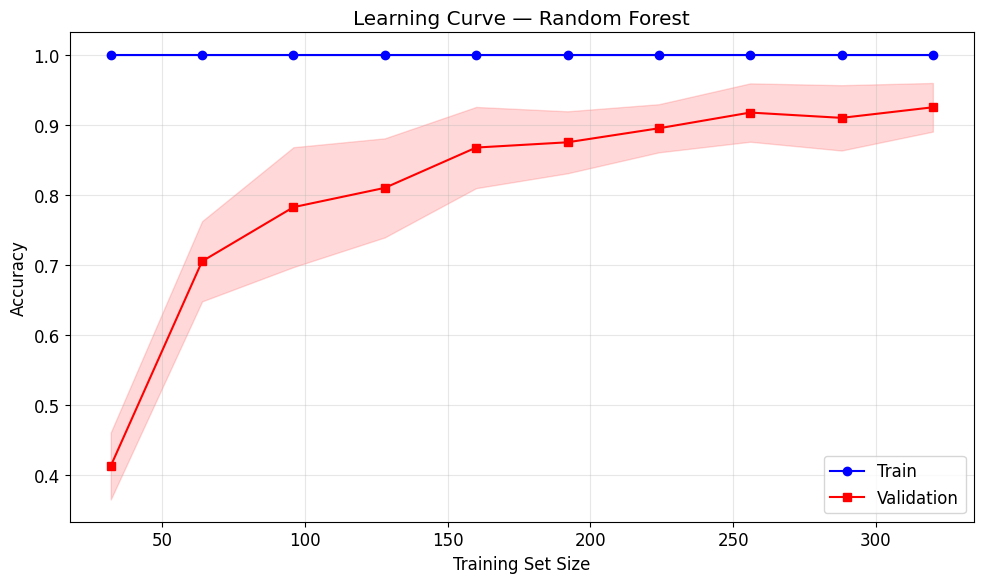

In [ ]:
# Learning curve: how performance changes with training set size
train_sizes_frac = np.linspace(0.1, 1.0, 10)
train_means, val_means = [], []
train_stds, val_stds = [], []

for frac in train_sizes_frac:
    fold_train_scores, fold_val_scores = [], []

    for train_idx, val_idx in StratifiedKFold(num_folds=5, shuffle=True, random_state=42).split(X_dev, y_dev):
        # Subsample the training fold
        n_use = max(1, int(frac * len(train_idx)))
        sub_train_idx = train_idx[:n_use]

        rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
        rf.fit(X_dev[sub_train_idx], y_dev[sub_train_idx])

        fold_train_scores.append(accuracy_score(y_dev[sub_train_idx], rf.predict(X_dev[sub_train_idx])))
        fold_val_scores.append(accuracy_score(y_dev[val_idx], rf.predict(X_dev[val_idx])))

    train_means.append(np.mean(fold_train_scores))
    train_stds.append(np.std(fold_train_scores))
    val_means.append(np.mean(fold_val_scores))
    val_stds.append(np.std(fold_val_scores))

train_means, val_means = np.array(train_means), np.array(val_means)
train_stds, val_stds = np.array(train_stds), np.array(val_stds)

actual_sizes = (train_sizes_frac * len(X_dev) * 0.8).astype(int)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(actual_sizes, train_means, "o-", label="Train", color="blue")
ax.fill_between(actual_sizes, train_means - train_stds, train_means + train_stds, alpha=0.15, color="blue")
ax.plot(actual_sizes, val_means, "s-", label="Validation", color="red")
ax.fill_between(actual_sizes, val_means - val_stds, val_means + val_stds, alpha=0.15, color="red")
ax.set_xlabel("Training Set Size")
ax.set_ylabel("Accuracy")
ax.set_title("Learning Curve — Random Forest")
ax.legend()
plt.tight_layout()
plt.show()

SVC (RBF)           : 0.9650 ± 0.0278  folds=[0.95  1.    0.95  0.925 0.925 1.    0.975 0.975 1.    0.95 ]
k-NN (k=5)          : 0.9350 ± 0.0320  folds=[0.95  0.925 0.925 0.875 0.925 0.95  0.95  0.95  1.    0.9  ]
Random Forest       : 0.9175 ± 0.0488  folds=[0.95  0.85  0.875 0.825 0.925 0.925 0.975 0.95  0.975 0.925]


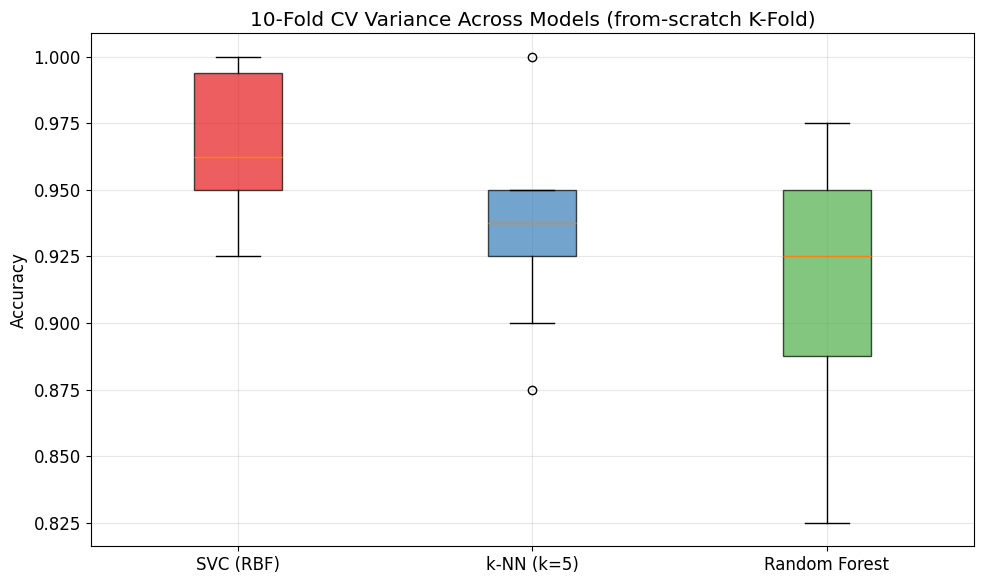

In [ ]:
# Variance across folds for different models
models_to_compare = {
    "SVC (RBF)": (SVC, {"kernel": "rbf", "C": 10, "gamma": 0.01}),
    "k-NN (k=5)": (KNeighborsClassifier, {"n_neighbors": 5}),
    "Random Forest": (RandomForestClassifier, {"n_estimators": 100, "max_depth": 10, "random_state": 42}),
}

fig, ax = plt.subplots(figsize=(10, 6))
all_fold_scores = {}

for name, (model_cls, params) in models_to_compare.items():
    scores = cross_val_score_scratch(model_cls, params, X_dev, y_dev, num_folds=10, random_state=42)
    all_fold_scores[name] = scores
    print(f"{name:20s}: {scores.mean():.4f} ± {scores.std():.4f}  folds={scores}")

bp = ax.boxplot(
    [all_fold_scores[name] for name in models_to_compare],
    labels=list(models_to_compare.keys()),
    patch_artist=True,
)
box_colors = ["#e41a1c", "#377eb8", "#4daf4a"]
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("Accuracy")
ax.set_title("10-Fold CV Variance Across Models (from-scratch K-Fold)")
plt.tight_layout()
plt.show()

---
# Summary

## PCA

| Aspect | Recommendation |
|--------|---------------|
| When to use | High-dimensional data, visualization, decorrelation, noise reduction |
| Preprocessing | **Always standardize** if features have different scales |
| Choosing $k$ | Cumulative EVR ≥ 95%, scree plot elbow, or downstream CV performance |
| Implementation | Use SVD (numerically stable); eigendecomposition for understanding |
| Limitations | Linear only; see kernel PCA or autoencoders for nonlinear manifolds |

## LDA

| Aspect | Recommendation |
|--------|---------------|
| When to use | Classification preprocessing when labels are available |
| Max components | $C - 1$ (limited by rank of $S_B$) |
| Assumptions | Gaussian class-conditional densities, shared covariance (violated → regularize) |
| vs PCA | Use PCA for general reduction, LDA when class separation is the goal |
| Regularization | Always add $\epsilon I$ to $S_W$ to avoid singularity |

## Cross-Validation and Hyperparameter Search

| Aspect | Recommendation |
|--------|---------------|
| Default CV | Stratified 5-fold or 10-fold |
| Small datasets | LOO-CV or repeated K-fold |
| Large datasets | Simple hold-out or 3-fold (compute savings) |
| GridSearch | Small, discrete grids; when exhaustive coverage is needed |
| RandomSearch | Large/continuous spaces; usually matches grid with fewer evaluations |
| Bayesian Opt | Expensive evaluations (deep learning); limited compute budget |
| Final evaluation | **Always** hold out a test set untouched during model selection |
| Reporting | Report mean ± std of CV scores, plus final test score |

### Common Pitfalls

1. **Data leakage:** Fitting PCA/scaler on full data before splitting → optimistic estimates. Always fit on training fold only.
2. **Test set peeking:** Tuning hyperparameters on the test set → no unbiased estimate remains.
3. **Ignoring variance:** Reporting only mean CV score hides instability — always report standard deviation.
4. **Too many hyperparameters:** Searching a huge grid increases the risk of finding a "lucky" configuration that doesn't generalize.
5. **Not using pipelines:** Preprocessing must be inside the CV loop to avoid leakage.